# Tutorial: Chicago dataset adapter (deterministic local snapshot)

This notebook demonstrates an end-to-end workflow on Chicago crime data using a **local snapshot CSV** stored in `docs/tutorials/data`.

The sequence is:

1. (Optional) show how the snapshot can be refreshed from the API,
2. load local data deterministically,
3. adapt event tables into `CountsTensor`,
4. fit + forecast,
5. run rolling-origin evaluation.

The executed path is deterministic and does **not** require network access.


In [1]:
import time
NB_START = time.perf_counter()

from datetime import date
from pathlib import Path

import jax
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from motac import (
    EventTable,
    GridSpec,
    make_grid_stencil,
    chicago_to_counts,
    fetch_chicago_crimes,
    HawkesModelSpec,
    MobilityHawkesModel,
    FitConfig,
    rolling_backtest,
)

plt.style.use('seaborn-v0_8-whitegrid')

# Support execution from repo root (docs/tutorials/data) or notebook dir (data).
DATA_DIR = Path('docs/tutorials/data')
if not DATA_DIR.exists():
    DATA_DIR = Path('data')


/home/oj/.local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
devices = jax.devices()
gpu_devices = [d for d in devices if d.platform == 'gpu']

print('Detected devices:', devices)
print('Default backend:', jax.default_backend())
print('JIT remains enabled unless JAX_DISABLE_JIT is set externally.')
if gpu_devices:
    print(f'GPU devices available: {len(gpu_devices)}')
else:
    print('No CUDA-enabled JAX backend detected for this run.')


Detected devices: [CpuDevice(id=0)]
Default backend: cpu
JIT remains enabled unless JAX_DISABLE_JIT is set externally.
No CUDA-enabled JAX backend detected for this run.


## Optional: refresh the local Chicago snapshot

The cell below is intentionally disabled by default so this notebook stays deterministic.

If you want to refresh the local snapshot manually, set `RUN_NETWORK_FETCH = True` and execute once.


In [3]:
RUN_NETWORK_FETCH = False

if RUN_NETWORK_FETCH:
    _ = fetch_chicago_crimes(
        start=date(2024, 1, 1),
        end=date(2025, 12, 31),
        use_sodapy=False,
        limit=500_000,
        cache_dir=DATA_DIR,
    )
    print('Snapshot refreshed under docs/tutorials/data/')
else:
    print('Skipping network fetch; using local snapshot CSV only.')


Skipping network fetch; using local snapshot CSV only.


## Load and curate the local snapshot

To keep model runtime reasonable while preserving structure, we:

- keep the top four crime categories,
- cap events at a deterministic sample size,
- use weekly time bins (`dt_days=7`) for adaptation and modelling.


In [4]:
snapshot_path = DATA_DIR / 'chicago_2024-01-01_2025-12-31.csv'
if not snapshot_path.exists():
    raise FileNotFoundError(f'Missing snapshot: {snapshot_path}')

df_raw = pd.read_csv(snapshot_path, low_memory=False)
required_cols = {'date', 'latitude', 'longitude', 'primary_type'}
missing = required_cols - set(df_raw.columns)
if missing:
    raise ValueError(f'Chicago snapshot missing required columns: {sorted(missing)}')

df = df_raw.copy()
df['date'] = pd.to_datetime(df['date'], errors='coerce').dt.floor('D')
df = df.dropna(subset=['date', 'latitude', 'longitude', 'primary_type']).copy()
df['primary_type'] = df['primary_type'].astype(str)

# Focus on the most frequent marks for a compact but realistic demo.
top_marks = df['primary_type'].value_counts().head(4).index.tolist()
df = df[df['primary_type'].isin(top_marks)].copy()

MAX_EVENTS = 80_000
if len(df) > MAX_EVENTS:
    df = df.sample(MAX_EVENTS, random_state=2026)

df = df.sort_values('date').reset_index(drop=True)

print('Loaded rows (post-filter):', len(df))
print('Date range:', df['date'].min().date(), '->', df['date'].max().date())
print('Top marks:', top_marks)
df.head(3)


Loaded rows (post-filter): 80000
Date range: 2024-01-01 -> 2024-10-06
Top marks: ['THEFT', 'BATTERY', 'CRIMINAL DAMAGE', 'ASSAULT']


,id,case_number,date,block,iucr,primary_type,description,location_description,arrest,domestic,...,ward,community_area,fbi_code,x_coordinate,y_coordinate,year,updated_on,latitude,longitude,location
0,13326051,JH101407,2024-01-01,052XX N KENMORE AVE,0560,ASSAULT,SIMPLE,APARTMENT,False,False,...,48,77,08A,1168307,1934942,2024,2024-12-21T15:40:46.000,41.977017,-87.656432,"{'latitude': '41.977016728', 'longitude': '-87..."
1,13325121,JH100358,2024-01-01,122XX S SANGAMON ST,0486,BATTERY,DOMESTIC BATTERY SIMPLE,RESIDENCE,False,True,...,21,53,08B,1172208,1823718,2024,2024-12-21T15:40:46.000,41.671722,-87.645362,"{'latitude': '41.671722201', 'longitude': '-87..."
2,13324972,JH100254,2024-01-01,011XX S HAMILTON AVE,0820,THEFT,$500 AND UNDER,PARKING LOT / GARAGE (NON RESIDENTIAL),False,False,...,27,28,06,1162121,1895023,2024,2024-12-21T15:40:46.000,41.867608,-87.680299,"{'latitude': '41.867608211', 'longitude': '-87..."


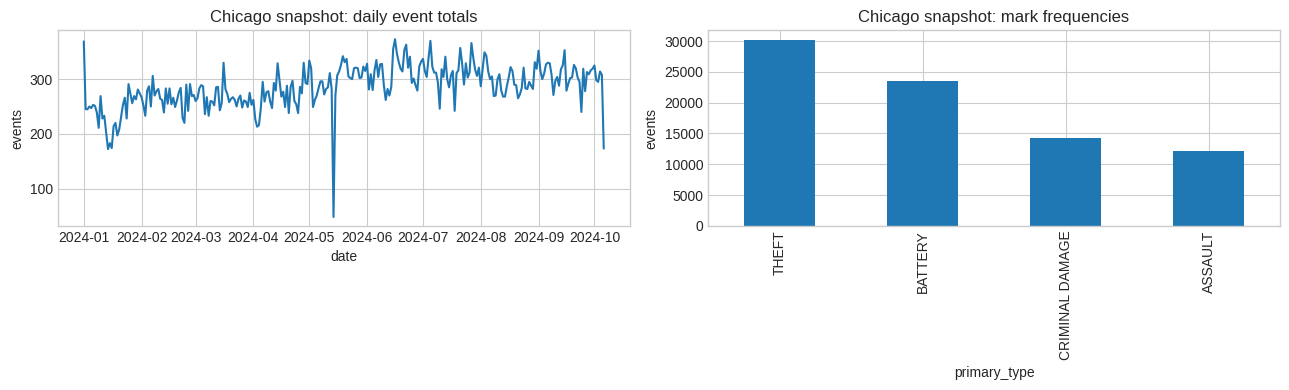

In [5]:
daily_totals = (
    df.groupby('date', as_index=False)
      .size()
      .rename(columns={'size': 'count'})
)
mark_totals = df['primary_type'].value_counts().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(daily_totals['date'], daily_totals['count'])
axes[0].set_title('Chicago snapshot: daily event totals')
axes[0].set_xlabel('date')
axes[0].set_ylabel('events')

mark_totals.plot(kind='bar', ax=axes[1])
axes[1].set_title('Chicago snapshot: mark frequencies')
axes[1].set_xlabel('primary_type')
axes[1].set_ylabel('events')

plt.tight_layout()


## Adapt event table to `CountsTensor`

We build a data-driven grid extent from robust quantiles (1% / 99%) so extreme outliers do not dominate the lattice geometry.


In [6]:
lon_q = df['longitude'].quantile([0.01, 0.99]).to_numpy()
lat_q = df['latitude'].quantile([0.01, 0.99]).to_numpy()

lon_min, lon_max = float(lon_q[0]), float(lon_q[1])
lat_min, lat_max = float(lat_q[0]), float(lat_q[1])

pad_lon = max(1e-3, 0.05 * (lon_max - lon_min))
pad_lat = max(1e-3, 0.05 * (lat_max - lat_min))

extent = (
    lon_min - pad_lon,
    lon_max + pad_lon,
    lat_min - pad_lat,
    lat_max + pad_lat,
)

grid = GridSpec(shape=(10, 10), extent=extent)

events = EventTable(
    df=df,
    time_col='date',
    lat_col='latitude',
    lon_col='longitude',
    mark_col='primary_type',
)

counts = chicago_to_counts(events, grid, marks=top_marks, dt_days=7)
print('Counts tensor shape [T, J, M]:', counts.y.shape)
print('Marks:', counts.marks)
print('Total events represented:', float(np.asarray(counts.y).sum()))


Counts tensor shape [T, J, M]: (40, 100, 4)
Marks: ('THEFT', 'BATTERY', 'CRIMINAL DAMAGE', 'ASSAULT')
Total events represented: 80000.0


## Fit, forecast, and evaluate

This run uses a small MAP-ensemble fit for a fast but complete tutorial workflow.


Forecast sample shape: (48, 4, 100, 4)
Forecast total mean count: 8855.396484375


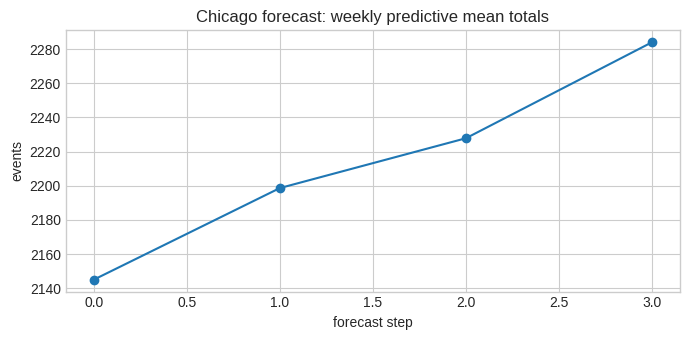

In [7]:
stencil = make_grid_stencil(kind='gaussian', size=3, sigma=1.0)
counts = counts.with_connectivity(stencil)

spec = HawkesModelSpec(marks=counts.marks, temporal_bases=2, observation='poisson')
model = MobilityHawkesModel(spec)

fit = model.fit(
    counts,
    method='map_ensemble',
    config=FitConfig(map_steps=16, map_ensemble_size=2, map_patience=6),
    seed=123,
)

forecast_horizon = 4
fc = model.forecast(counts, fit, horizon=forecast_horizon, num_samples=48, seed=456)

print('Forecast sample shape:', fc.y_samples.shape)
print('Forecast total mean count:', float(np.asarray(fc.mean).sum()))

pred_weekly = np.asarray(fc.mean).sum(axis=(1, 2))
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(np.arange(len(pred_weekly)), pred_weekly, marker='o')
ax.set_title('Chicago forecast: weekly predictive mean totals')
ax.set_xlabel('forecast step')
ax.set_ylabel('events')
plt.tight_layout()


In [8]:
bt = rolling_backtest(
    model,
    counts,
    horizon=4,
    step=8,
    min_train=max(24, counts.num_time // 2),
    fit_method='map_ensemble',
    fit_config=FitConfig(map_steps=10, map_ensemble_size=1, map_patience=4),
    forecast_samples=24,
    seed=789,
)

if bt.metrics.empty:
    print('Backtest produced no splits. Increase series length or reduce min_train.')
else:
    cols = ['log_score', 'crps', 'coverage_90', 'hotspot_recall']
    print('Backtest split count:', len(bt.splits))
    print(bt.metrics[cols].describe().T)


Backtest split count: 2
                count      mean       std       min       25%       50%  \
log_score         2.0 -2.191628  0.013009 -2.200827 -2.196227 -2.191628   
crps              2.0  2.504852  0.036504  2.479040  2.491946  2.504852   
coverage_90       2.0  0.649687  0.015468  0.638750  0.644219  0.649687   
hotspot_recall    2.0  1.000000  0.000000  1.000000  1.000000  1.000000   

                     75%       max  
log_score      -2.187029 -2.182430  
crps            2.517758  2.530664  
coverage_90     0.655156  0.660625  
hotspot_recall  1.000000  1.000000  


## Common adapter pitfalls and reproducibility checklist

Before trusting forecast outputs, confirm:

- you are using a frozen local snapshot file,
- timestamp/coordinate columns parse cleanly,
- mark taxonomy is explicit and stable,
- connectivity is attached before fit/forecast,
- seeds and fit settings are pinned for repeatability.


In [9]:
checklist = {
    'Snapshot file exists': snapshot_path.exists(),
    'No missing coordinates after preprocessing': not df[['latitude', 'longitude']].isna().any().any(),
    'At least three marks retained': len(counts.marks) >= 3,
    'Connectivity attached': counts.connectivity is not None,
}

for item, ok in checklist.items():
    print(f"{'[OK]' if ok else '[WARN]'} {item}")


[OK] Snapshot file exists
[OK] No missing coordinates after preprocessing
[OK] At least three marks retained
[OK] Connectivity attached


In [10]:
elapsed_sec = time.perf_counter() - NB_START
print(f'Notebook wall-clock runtime: {elapsed_sec:.2f} seconds ({elapsed_sec/60.0:.2f} minutes)')


Notebook wall-clock runtime: 11.87 seconds (0.20 minutes)
